# 04 · Linear models — RQ1: DLinear versus NLinear

> **RQ1.** How do DLinear and NLinear compare in forecasting capacity degradation and the resulting RUL, and how do
> degradation patterns (capacity regeneration, differences between NASA and CALCE cells) affect their relative
> performance?

| | |
|---|---|
| **Inputs** | `processed/cells/*`, `processed/cell_summary.csv`, `processed/regimes.csv` (from 02) |
| **Outputs** | `results/rq1_*.csv`, `results/rq1_hypotheses.json`, `figures/04_*.png` |

### Pre-registered hypotheses (fixed before this notebook was first run)

* **H1a** — NLinear achieves lower relative RUL error than DLinear across all units.
* **H1b** — NLinear's advantage over DLinear is larger in high-regeneration cells than in low-regeneration cells
  (subgroups fixed in notebook 02).

Verdicts are *supported* / *contradicted* (significant after Holm correction, in / against the predicted direction) or
*not detected* (not significant — insufficient evidence, **not** equivalence).

### Models

| Model | Role |
|---|---|
| **DLinear** | trend (moving average) + remainder, one linear layer each |
| **NLinear** | subtract the last value, one linear layer, add it back |
| **Linear** | a single linear layer — reference for how much of any difference comes from parameterisation |
| **LinearTrend** | straight line through the window, extended — the classical threshold-crossing baseline |
| **Persistence** | repeat the last value — never crosses the threshold, so always censored |

All three learned models implement a linear map of the window (Toner & Darlow, 2024); they differ through
parameterisation, initialisation and early stopping. Section 6 measures that directly.

In [3]:
# Make the repository importable, locally or on Google Colab.
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    # Once per session:
    #   !git clone https://github.com/<your-account>/battery-rul-linear.git /content/battery-rul-linear
    #   %pip install -q -r /content/battery-rul-linear/requirements.txt
    # Raw data on Drive: MyDrive/battery_rul/data/NASA_PCoE/*.mat and .../CALCE_CX2/CX2_*/
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/battery-rul-linear")
    os.environ.setdefault("BATTERY_RUL_DATA", "/content/drive/MyDrive/battery_rul/data")

ROOT = Path.cwd().resolve()
if not (ROOT / "battery_rul").is_dir():
    ROOT = ROOT.parent                          # launched from notebooks/
os.environ.setdefault("BATTERY_RUL_ROOT", str(ROOT))
sys.path.insert(0, str(ROOT))

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from battery_rul import config
from battery_rul.dataset import load_cells, loco_folds
from battery_rul.evaluation import UNIT_COLS, seed_average, summary_table, wide
from battery_rul.experiment import ExperimentSettings, baseline_spec, linear_spec, rollout_examples, run_experiment
from battery_rul.models.linear import effective_map
from battery_rul.plotting import (INK_2, error_distribution, metric_vs_setting, rollout_panel, savefig,
                                  setup_style, style_of)
from battery_rul.report import HYPOTHESES, HypothesisResult, describe, finalize
from battery_rul.stats import friedman, pairwise, subgroup_difference, wilcoxon
from battery_rul.utils import markdown_table, record_run, save_json, save_table, timer

pd.set_option("display.width", 170)
setup_style()
record_run("04_modelling_linears")
cells = load_cells()
REF = config.LABELS.primary_reference
folds = loco_folds(cells, REF)
regimes = pd.read_csv(config.PROCESSED_DIR / "regimes.csv")
METRIC = config.PRIMARY_METRIC
LINEARS = list(config.LINEAR_MODELS)
MODELS = LINEARS + list(config.BASELINE_MODELS)
print(f"{len(folds)} folds | seeds {config.LINEAR_SEEDS} | primary metric: {METRIC} | EOL reference: {REF}")

11 folds | seeds (0, 1, 2, 3, 4) | primary metric: rel_abs_rul_error | EOL reference: rated


## 1. Train and evaluate

For every fold and seed: train on the training cells (early stopping on the last 20% of each training cell's windows),
roll out from each origin of the test cell until the forecast stays below the threshold, score. Baselines have no
parameters and run once.

In [5]:
specs = [linear_spec(m) for m in LINEARS] + [baseline_spec(m) for m in config.BASELINE_MODELS]
with timer("RQ1 main run"):
    records, fits, models = run_experiment(cells, folds, specs, config.LINEAR_SEEDS,
                                           ExperimentSettings(reference=REF), keep_models=True)
save_table(records, "rq1_records")
save_table(fits, "rq1_fits")
print(f"{len(records)} scored forecasts from {len(fits)} trained models")

  CALCE:CX2_16: 10027 training windows from 6 cells, 3 origins, roll-out cap 1254
  CALCE:CX2_33: 10346 training windows from 6 cells, 3 origins, roll-out cap 1500
  CALCE:CX2_34: 10307 training windows from 6 cells, 3 origins, roll-out cap 1500
  CALCE:CX2_35: 10230 training windows from 6 cells, 3 origins, roll-out cap 1500
  CALCE:CX2_36: 10073 training windows from 6 cells, 3 origins, roll-out cap 1500
  CALCE:CX2_37: 10760 training windows from 6 cells, 3 origins, roll-out cap 1500
  CALCE:CX2_38: 10083 training windows from 6 cells, 3 origins, roll-out cap 1500
  NASA:B0005: 399 training windows from 3 cells, 3 origins, roll-out cap 141
  NASA:B0006: 399 training windows from 3 cells, 3 origins, roll-out cap 141
  NASA:B0007: 399 training windows from 3 cells, 3 origins, roll-out cap 111
  NASA:B0018: 435 training windows from 3 cells, 2 origins, roll-out cap 141
RQ1 main run: 263.2s
544 scored forecasts from 187 trained models


## 2. Results

Seeds are averaged within each (cell, origin) unit first; every statistic below is computed over units.

In [6]:
units = seed_average(records)
save_table(units, "rq1_units")
overall = summary_table(units)
save_table(overall, "rq1_summary")
print(markdown_table(overall))
overall

| model       |   n_units |   median_rel_err |   mean_rel_err |   median_abs_err_cycles |   mean_signed_err_cycles |   alpha_lambda_acc |   censor_rate |   median_block_rmse_Ah |   median_traj_rmse_Ah |
|:------------|----------:|-----------------:|---------------:|------------------------:|-------------------------:|-------------------:|--------------:|-----------------------:|----------------------:|
| NLinear     |        32 |            0.196 |          0.318 |                  38.900 |                  -31.538 |              0.512 |         0.000 |                  0.011 |                 0.023 |
| DLinear     |        32 |            0.238 |          0.388 |                  36.500 |                   39.562 |              0.444 |         0.000 |                  0.011 |                 0.026 |
| Linear      |        32 |            0.266 |          0.458 |                  54.600 |                   63.494 |              0.319 |         0.006 |                  0.011 |          

,model,n_units,median_rel_err,mean_rel_err,median_abs_err_cycles,mean_signed_err_cycles,alpha_lambda_acc,censor_rate,median_block_rmse_Ah,median_traj_rmse_Ah
3,NLinear,32,0.196374,0.318489,38.9,-31.53750,0.51250,0.00000,0.010617,0.022777
0,DLinear,32,0.238271,0.387539,36.5,39.56250,0.44375,0.00000,0.010966,0.026369
1,Linear,32,0.265800,0.458404,54.6,63.49375,0.31875,0.00625,0.010545,0.028703
2,LinearTrend,32,0.565664,1.352060,184.0,224.50000,0.09375,0.25000,0.013446,0.057173
4,Persistence,32,2.995248,3.618072,964.5,741.62500,0.00000,0.96875,0.014585,0.069426


In [7]:
by_dataset = summary_table(units, by=["dataset", "model"])
save_table(by_dataset, "rq1_summary_by_dataset")
by_dataset

,dataset,model,n_units,median_rel_err,mean_rel_err,median_abs_err_cycles,mean_signed_err_cycles,alpha_lambda_acc,censor_rate,median_block_rmse_Ah,median_traj_rmse_Ah
3,CALCE,NLinear,21,0.181622,0.190394,49.8,-53.085714,0.600000,0.000000,0.008865,0.015071
0,CALCE,DLinear,21,0.206835,0.287860,77.2,57.657143,0.523810,0.000000,0.008543,0.015895
1,CALCE,Linear,21,0.259298,0.310024,79.0,91.390476,0.361905,0.000000,0.009617,0.021819
2,CALCE,LinearTrend,21,0.620579,1.616475,311.0,333.952381,0.095238,0.285714,0.010985,0.056800
4,CALCE,Persistence,21,3.043127,3.859508,1120.0,1085.809524,0.000000,1.000000,0.009942,0.060747
5,NASA,DLinear,11,0.291667,0.577836,11.8,5.018182,0.290909,0.000000,0.036036,0.049743
6,NASA,Linear,11,0.300000,0.741676,12.0,10.236364,0.236364,0.018182,0.039943,0.053601
8,NASA,NLinear,11,0.372973,0.563035,13.8,9.600000,0.345455,0.000000,0.028150,0.042783
7,NASA,LinearTrend,11,0.458333,0.847267,18.0,15.545455,0.090909,0.181818,0.037246,0.059067
9,NASA,Persistence,11,2.810811,3.157149,94.0,84.545455,0.000000,0.909091,0.031408,0.091560


In [8]:
by_origin = units.pivot_table(index="model", columns="frac", values=METRIC, aggfunc="median")
by_origin.columns = [f"median rel. error @ {int(c * 100)}% life" for c in by_origin.columns]
save_table(by_origin.reset_index(), "rq1_by_origin")
by_origin

,median rel. error @ 25% life,median rel. error @ 50% life,median rel. error @ 75% life
model,,,
DLinear,0.254050,0.182979,0.291667
Linear,0.273312,0.187234,0.343023
LinearTrend,0.540240,1.189189,0.866667
NLinear,0.125202,0.208625,0.199200
Persistence,1.664710,3.043127,6.894737


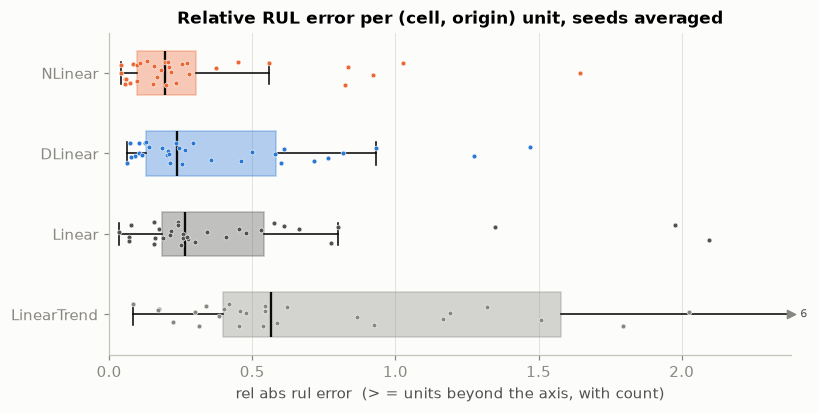

Persistence is omitted from the plot: it never crosses the threshold (censor rate 97%).


In [9]:
fig, ax = plt.subplots(figsize=(8, 3.8))
error_distribution(units, METRIC, [m for m in MODELS if m != "Persistence"], ax=ax,
                   title="Relative RUL error per (cell, origin) unit, seeds averaged")
savefig(fig, "04_error_distribution")
plt.show()
print("Persistence is omitted from the plot: it never crosses the threshold (censor rate "
      f"{overall.set_index('model').loc['Persistence', 'censor_rate']:.0%}).")

## 3. Statistical tests

Friedman omnibus over all five models on complete blocks, then pairwise Wilcoxon signed-rank tests with Holm
correction across the RQ1 comparison family, with matched-pairs rank-biserial effect sizes (positive = the first model
has *higher* error) and a bootstrap CI on the median paired difference.

In [10]:
table = wide(units, METRIC, MODELS)
omnibus = friedman(table)
save_json(omnibus, "rq1_friedman")
print(f"Friedman: chi2 = {omnibus['statistic']:.3f}, p = {omnibus['p_value']:.3g}, "
      f"{omnibus['n_units']} units x {omnibus['k_models']} models")

pairs = [("DLinear", "NLinear"), ("DLinear", "Linear"), ("NLinear", "Linear"),
         ("DLinear", "LinearTrend"), ("NLinear", "LinearTrend"), ("Linear", "LinearTrend")]
pw = pairwise(table, pairs)
save_table(pw, "rq1_pairwise")
pw.round(4)

Friedman: chi2 = 77.441, p = 6.07e-16, 32 units x 5 models


,model_a,model_b,n_units,median_a,median_b,median_diff,ci_low,ci_high,wilcoxon_W,p_value,rank_biserial,a_better_in,b_better_in,p_holm,significant
0,DLinear,NLinear,32,0.2383,0.1964,0.0311,-0.0170,0.1253,198.0,0.2240,0.2500,11,21,0.2626,False
1,DLinear,Linear,32,0.2383,0.2658,-0.0142,-0.0502,0.0000,171.0,0.1313,-0.3105,21,10,0.2626,False
2,NLinear,Linear,32,0.1964,0.2658,-0.1527,-0.2163,-0.0425,140.0,0.0194,-0.4697,22,10,0.0583,False
3,DLinear,LinearTrend,32,0.2383,0.5657,-0.3425,-0.9442,-0.1476,79.0,0.0003,-0.7008,25,7,0.0013,True
4,NLinear,LinearTrend,32,0.1964,0.5657,-0.3789,-0.8162,-0.2379,49.0,0.0000,-0.8144,26,6,0.0001,True
5,Linear,LinearTrend,32,0.2658,0.5657,-0.2956,-0.7488,-0.1524,78.0,0.0003,-0.7045,27,5,0.0013,True


## 4. Hypotheses H1a and H1b

In [11]:
dn = wide(units, METRIC, ["DLinear", "NLinear"])
diff = (dn["DLinear"] - dn["NLinear"]).rename("dlinear_minus_nlinear").reset_index()
diff = diff.merge(regimes[["cell", "regime"]], on="cell", how="left")

_, p_a = wilcoxon(dn["DLinear"], dn["NLinear"])
h1a = HypothesisResult("H1a", HYPOTHESES["H1a"], "Wilcoxon signed-rank, DLinear vs NLinear", len(dn),
                       float(np.median(diff["dlinear_minus_nlinear"])), "median(DLinear - NLinear) rel. error",
                       p_a, bool(np.median(diff["dlinear_minus_nlinear"]) > 0))

hi = diff.loc[diff["regime"] == "high", "dlinear_minus_nlinear"]
lo = diff.loc[diff["regime"] == "low", "dlinear_minus_nlinear"]
sg = subgroup_difference(hi, lo)
h1b = HypothesisResult("H1b", HYPOTHESES["H1b"], "Mann-Whitney U on paired differences, high vs low regeneration",
                       sg["n_a"] + sg["n_b"], float(np.median(hi) - np.median(lo)) if len(hi) and len(lo) else np.nan,
                       "median diff (high) - median diff (low)", sg["p_value"],
                       bool(len(hi) and len(lo) and np.median(hi) > np.median(lo)),
                       note=f"n_high = {sg['n_a']}, n_low = {sg['n_b']}")
rq1 = finalize([h1a, h1b])
save_json([r.as_dict() for r in rq1], "rq1_hypotheses")
save_table(pd.DataFrame([r.as_dict() for r in rq1]), "rq1_hypotheses")
print(describe(rq1))

H1a: NOT DETECTED
    NLinear achieves lower relative RUL error than DLinear across all units.
    Wilcoxon signed-rank, DLinear vs NLinear; n = 32; median(DLinear - NLinear) rel. error = +0.0311; p = 0.224, Holm p = 0.448
H1b: NOT DETECTED
    NLinear's advantage over DLinear is larger in high-regeneration cells than in low-regeneration cells.
    Mann-Whitney U on paired differences, high vs low regeneration; n = 32; median diff (high) - median diff (low) = -0.0011; p = 0.9848, Holm p = 0.9848
    note: n_high = 14, n_low = 18


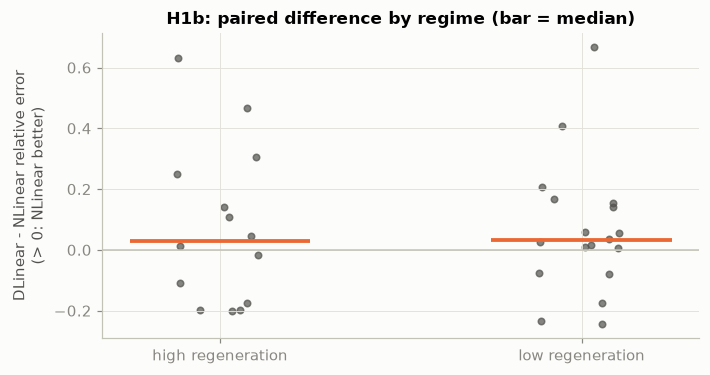

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for i, (reg, g) in enumerate(diff.groupby("regime")):
    x = np.full(len(g), i) + np.random.default_rng(0).uniform(-0.12, 0.12, len(g))
    ax.scatter(x, g["dlinear_minus_nlinear"], s=18, color=INK_2, alpha=0.7)
    ax.hlines(np.median(g["dlinear_minus_nlinear"]), i - 0.25, i + 0.25, color="#eb6834", lw=2.5)
ax.axhline(0, color="#c3c2b7", lw=1)
ax.set_xticks(range(diff["regime"].nunique()), [f"{r} regeneration" for r in sorted(diff["regime"].unique())])
ax.set(ylabel="DLinear - NLinear relative error\n(> 0: NLinear better)", title="H1b: paired difference by regime "
       "(bar = median)")
savefig(fig, "04_h1b_regimes")
plt.show()

## 5. Roll-outs, seed variability and training behaviour

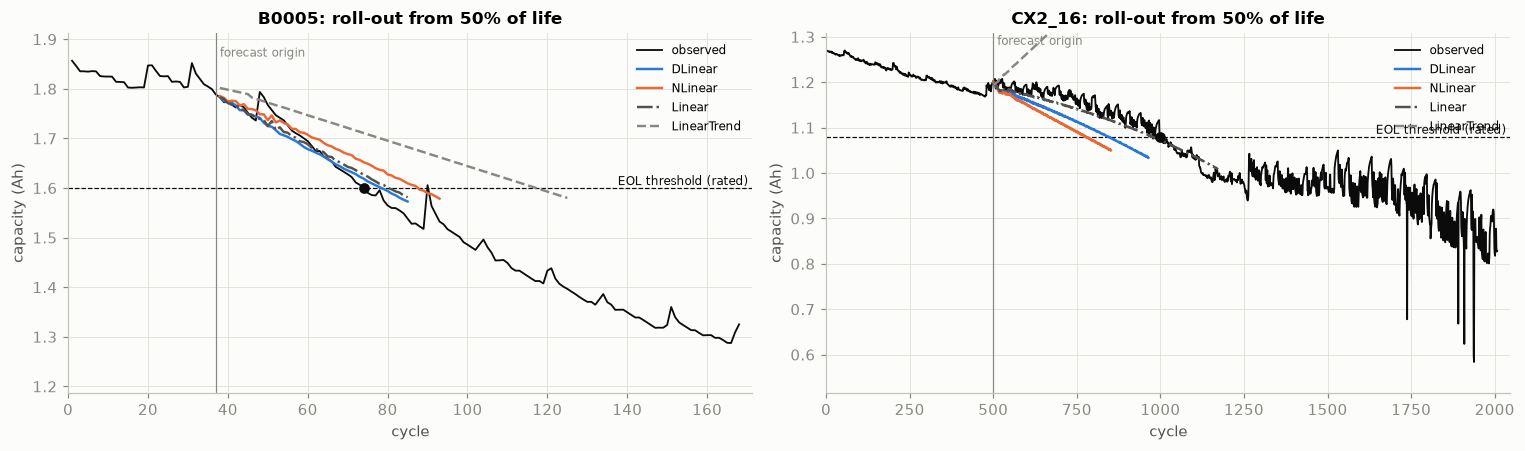

In [13]:
settings = ExperimentSettings(reference=REF)
examples = rollout_examples(models, cells, folds, settings, ["DLinear", "NLinear", "Linear", "LinearTrend"])
save_table(examples, "rq1_rollout_examples")
show = []
for ds in ("NASA", "CALCE"):
    cands = sorted({f.test for f in folds if f.dataset == ds})
    if cands:
        show.append(cands[0])
fig, axes = plt.subplots(1, len(show), figsize=(7 * len(show), 4.2), squeeze=False)
for ax, name in zip(axes[0], show):
    rollout_panel(examples, cells[name], 0.5, REF, ax=ax)
fig.tight_layout()
savefig(fig, "04_rollouts")
plt.show()

In [14]:
seed_sd = (records[records["family"] == "linear"].groupby(["model", *UNIT_COLS])[METRIC].std()
           .groupby("model").median().rename("median across units of seed SD").to_frame())
save_table(seed_sd.reset_index(), "rq1_seed_variability")
if len(config.LINEAR_SEEDS) < 2:
    print("one seed only (quick mode): seed variability is undefined")
seed_sd

,median across units of seed SD
model,
DLinear,0.085855
Linear,0.079598
NLinear,0.048804


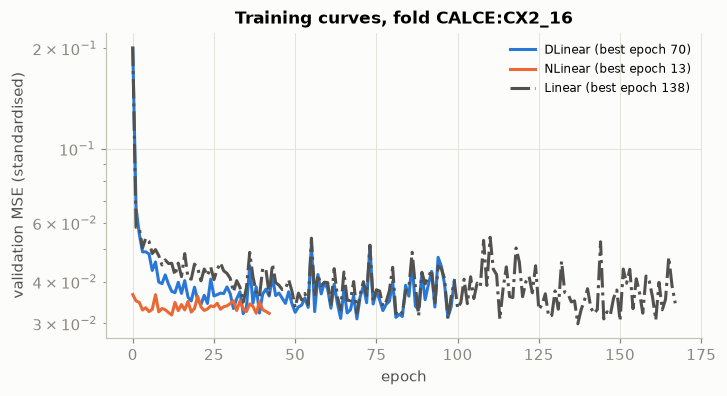

,best_epoch,epochs_run,train_seconds,n_params
model,,,,
DLinear,70.0,100.0,2.003975,1568.0
Linear,119.0,149.0,2.026246,784.0
NLinear,45.0,75.0,0.854773,784.0


In [15]:
fold0 = folds[0].fold_id
fig, ax = plt.subplots(figsize=(7, 3.6))
for m in LINEARS:
    f = models[(m, fold0, config.LINEAR_SEEDS[0])]
    st = style_of(m)
    ax.plot(f.history["val"], label=f"{m} (best epoch {f.best_epoch})", color=st["color"], ls=st["linestyle"])
ax.set(yscale="log", xlabel="epoch", ylabel="validation MSE (standardised)", title=f"Training curves, fold {fold0}")
ax.legend(fontsize=8)
savefig(fig, "04_training_curves")
plt.show()
fits[fits["family"] == "linear"].groupby("model")[["best_epoch", "epochs_run", "train_seconds", "n_params"]].median()

## 6. Same function class, different solutions

Each trained model is reduced to the single matrix *W* it implements (`effective_map`). The cosine similarity between
two models' *W* on the same fold and seed says how close gradient descent brought them to the same linear map. The row
sums of *W* show level preservation: exactly 1 for NLinear by construction; for DLinear and Linear, whatever training
produced.

In [16]:
sim_rows = []
for f in folds:
    for s in config.LINEAR_SEEDS:
        W = {m: effective_map(models[(m, f.fold_id, s)])["W"] for m in LINEARS}
        cos = lambda a, b: float((a * b).sum() / (np.linalg.norm(a) * np.linalg.norm(b)))
        sim_rows.append({"fold": f.fold_id, "dataset": f.dataset, "seed": s,
                         "cos(DLinear, Linear)": cos(W["DLinear"], W["Linear"]),
                         "cos(DLinear, NLinear)": cos(W["DLinear"], W["NLinear"]),
                         "cos(NLinear, Linear)": cos(W["NLinear"], W["Linear"]),
                         "rowsum DLinear": float(W["DLinear"].sum(axis=1).mean()),
                         "rowsum NLinear": float(W["NLinear"].sum(axis=1).mean()),
                         "rowsum Linear": float(W["Linear"].sum(axis=1).mean())})
similarity = pd.DataFrame(sim_rows)
save_table(similarity, "rq1_weight_similarity")
similarity.groupby("dataset").median(numeric_only=True).drop(columns="seed").round(3)

,"cos(DLinear, Linear)","cos(DLinear, NLinear)","cos(NLinear, Linear)",rowsum DLinear,rowsum NLinear,rowsum Linear
dataset,,,,,,
CALCE,0.840,0.988,0.872,1.015,1.0,1.018
NASA,0.615,0.819,0.851,0.981,1.0,0.983


## 7. Sensitivity: end of life at 80% of *initial* capacity

The same models and seeds, scored against the alternative EOL convention. If H1a's verdict changes, the conclusion
depends on the threshold definition and must be reported that way.

In [17]:
folds_init = loco_folds(cells, "initial")
with timer("RQ1 sensitivity run (initial reference)"):
    rec_init, _, _ = run_experiment(cells, folds_init, [linear_spec("DLinear"), linear_spec("NLinear")],
                                    config.LINEAR_SEEDS, ExperimentSettings(reference="initial", arm="initial_ref"),
                                    log=lambda m: None)
save_table(rec_init, "rq1_records_initial_reference")
units_init = seed_average(rec_init)
dn_i = wide(units_init, METRIC, ["DLinear", "NLinear"])
_, p_i = wilcoxon(dn_i["DLinear"], dn_i["NLinear"])
med_i = float(np.median(dn_i["DLinear"] - dn_i["NLinear"]))
sens = pd.DataFrame([
    {"reference": "rated (primary)", "n_units": len(dn), "median_DLinear_minus_NLinear": h1a.effect,
     "p_value": h1a.p_value},
    {"reference": "initial (sensitivity)", "n_units": len(dn_i), "median_DLinear_minus_NLinear": med_i,
     "p_value": p_i},
])
save_table(sens, "rq1_reference_sensitivity")
sens

RQ1 sensitivity run (initial reference): 162.7s


,reference,n_units,median_DLinear_minus_NLinear,p_value
0,rated (primary),32,0.031100,0.223979
1,initial (sensitivity),33,0.064516,0.023662


## 8. Summary

Generated from the results above.

In [18]:
ov = overall.set_index("model")
best = ov.drop(index=["Persistence"]).sort_values("median_rel_err").index[0]
print(f"Lowest median relative RUL error: {best} ({ov.loc[best, 'median_rel_err']:.3f}); "
      f"LinearTrend baseline {ov.loc['LinearTrend', 'median_rel_err']:.3f}.")
for m in LINEARS:
    print(f"  {m:8s} median rel. error {ov.loc[m, 'median_rel_err']:.3f} | alpha-lambda accuracy "
          f"{ov.loc[m, 'alpha_lambda_acc']:.0%} | censored {ov.loc[m, 'censor_rate']:.0%} | "
          f"mean signed error {ov.loc[m, 'mean_signed_err_cycles']:+.1f} cycles")
print()
print(describe(rq1))
same_sign = np.sign(med_i) == np.sign(h1a.effect)
print(f"\nSensitivity (initial reference): median DLinear - NLinear = {med_i:+.4f}, p = {p_i:.3g} -> direction "
      f"{'unchanged' if same_sign else 'REVERSED'} relative to the rated reference.")
print("next: 05_modelling_tree_ml_models.ipynb (RQ2)")

Lowest median relative RUL error: NLinear (0.196); LinearTrend baseline 0.566.
  DLinear  median rel. error 0.238 | alpha-lambda accuracy 44% | censored 0% | mean signed error +39.6 cycles
  NLinear  median rel. error 0.196 | alpha-lambda accuracy 51% | censored 0% | mean signed error -31.5 cycles
  Linear   median rel. error 0.266 | alpha-lambda accuracy 32% | censored 1% | mean signed error +63.5 cycles

H1a: NOT DETECTED
    NLinear achieves lower relative RUL error than DLinear across all units.
    Wilcoxon signed-rank, DLinear vs NLinear; n = 32; median(DLinear - NLinear) rel. error = +0.0311; p = 0.224, Holm p = 0.448
H1b: NOT DETECTED
    NLinear's advantage over DLinear is larger in high-regeneration cells than in low-regeneration cells.
    Mann-Whitney U on paired differences, high vs low regeneration; n = 32; median diff (high) - median diff (low) = -0.0011; p = 0.9848, Holm p = 0.9848
    note: n_high = 14, n_low = 18

Sensitivity (initial reference): median DLinear - NLin